In [160]:
import os

import pandas as pd
import numpy as np
import pickle

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

import seaborn as sns
from ast import literal_eval

from typing import Dict, List, Optional, Tuple
from datetime import datetime, timedelta
import time

import glob
import json
import requests
from pprint import pprint

from concurrent.futures import ProcessPoolExecutor, as_completed
import logging

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, classification_report
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.model_selection import RandomizedSearchCV

import multiprocessing as mp

# from mlxtend.feature_selection import SequentialFeatureSelector as sfs
from linearmodels.panel import PanelOLS

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant

from scipy import stats
from scipy.stats import pearsonr, spearmanr, f_oneway
from scipy.stats.mstats import winsorize

import sklearn.inspection
from sklearn.inspection import PartialDependenceDisplay
from matplotlib import rcParams
# rcParams['figure.figsize'] = 6,6

# import plotly.express as px
import time
import requests
import re
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
# plt.style.use('seaborn-v0_8')
# sns.set_palette("husl")

In [11]:
# !pip install --upgrade pip
# !pip install linearmodels
# !pip install xlsxwriter

In [12]:
np.random.seed(42)

In [13]:
def grid_search_cv(param_grid, model, X_train_scaled, y_train, X_test_scaled, y_test):

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5, 
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train_scaled, y_train)

    best_params = grid_search.best_params_
    best_model = grid_search.best_estimator_

    print("Best parameters found:", best_params)
    print("Best cross-validation score (negative MSE):", grid_search.best_score_)

    model_pred = best_model.predict(X_test_scaled)
    model_rmse = np.sqrt(mean_squared_error(y_test, model_pred))
    model_r2 = r2_score(y_test, model_pred)

    print(f"Test RMSE: {model_rmse:.4f}")
    print(f"Test R²: {model_r2:.4f}")
    
    return best_params, best_model

In [14]:
def prepare_data(df, features, target_col='next_day_3_log_return'):

    data = df.copy()
    
    data = data.dropna(subset=[target_col])
    data.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    X = data[features]
    y = data[target_col]
    
    categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
    
    if categorical_cols:
        X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
    
    for col in X.columns:
        if X[col].isnull().sum() > 0:
            if X[col].dtype in ['int64', 'float64']:
#                 X[col].fillna(X[col].median(), inplace=True)
#                 X[col].fillna(X[col].mean(), inplace=True)
                X[col].fillna(0., inplace=True)
    
    return X, y

def data_train_test_split(df, features, target_col, q=2, test_size=0.1):
    X, y = prepare_data(df, features, target_col=target_col)

    y_bins = pd.qcut(y, q=q, labels=False, duplicates='drop')

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, 
#         stratify=y_bins
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

    y_train = y_train.reset_index(drop=True)
    y_test = y_test.reset_index(drop=True)
    print(round(y_train.mean(), 3), round(y_test.mean(), 3))
    
    return X_train_scaled, X_test_scaled, y_train, y_test

In [15]:
def scatter_regplot(x, y, **kws):
    ax = plt.gca()
    # Scatter plot
    ax.scatter(x, y, alpha=0.6, s=30, edgecolor='w', linewidth=0.5)
    # Линия регрессии
    sns.regplot(x=x, y=y, scatter=False, 
                line_kws={'color': 'red', 'alpha': 0.8, 'linewidth': 2})
    r, p_value = stats.pearsonr(x, y)
    ax.annotate(f'r = {r:.3f}', xy=(0.05, 0.95), xycoords='axes fraction',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8),
                fontsize=9)

def diag_kde(x, **kws):
    ax = plt.gca()
    sns.histplot(x, kde=True, stat="density", alpha=0.7, ax=ax)

    mean_val = x.mean()
    median_val = x.median()
    ax.axvline(mean_val, color='red', linestyle='--', alpha=0.8, label=f'Mean: {mean_val:.3f}')
    ax.axvline(median_val, color='green', linestyle='--', alpha=0.8, label=f'Median: {median_val:.3f}')
    if ax.get_subplotspec().is_first_row() and ax.get_subplotspec().is_first_col():
        ax.legend(loc='upper right', fontsize=8)

def lower_hexbin(x, y, **kws):
    ax = plt.gca()
    hb = ax.hexbin(x, y, gridsize=30, cmap='Blues', alpha=0.8, mincnt=1)
    plt.colorbar(hb, ax=ax, shrink=0.7)

In [16]:
def calculate_pvalues(df, method='pearson'):
    n = df.shape[1]
    p_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i == j:
                p_matrix[i, j] = 0
            else:
                if method == 'pearson':
                    corr, p_value = pearsonr(df.iloc[:, i], df.iloc[:, j])
                    p_matrix[i, j] = p_value
                elif method == 'spearman':
                    corr, p_value = spearmanr(df.iloc[:, i], df.iloc[:, j])
                    p_matrix[i, j] = p_value
    return pd.DataFrame(p_matrix, index=df.columns, columns=df.columns)

def annotate_with_pvalues(corr_matrix, p_matrix):
    annot_matrix = np.empty_like(corr_matrix, dtype=object)
    n = corr_matrix.shape[0]
    
    for i in range(n):
        for j in range(n):
            if i == j:
                annot_matrix[i, j] = '1.00'
            elif mask[i, j]: 
                annot_matrix[i, j] = ''
            else:
                corr_val = corr_matrix.iloc[i, j]
                p_val = p_matrix.iloc[i, j]
                
                stars = ''
                if p_val < 0.01:
                    stars = '***'
                elif p_val < 0.05:
                    stars = '**'
                elif p_val < 0.1:
                    stars = '*'
                
                annot_matrix[i, j] = f'{corr_val:.2f}{stars}'
    
    return annot_matrix

def plot_corr_matrix(corr_matrix, mask, annotations, title='Correlation with p-values'):
    plt.figure(figsize=(12, 10))
    heatmap = sns.heatmap(corr_matrix,
                mask=mask,
                annot=annotations,
                cmap='RdBu_r',
                center=0,
                square=True,
                fmt='', 
                linewidths=0.5,
                cbar_kws={'shrink': 0.8},
                annot_kws={'size': 9})

    plt.title(title, fontsize=16, pad=20)

    legend_text = '\n'.join([
        '*** p < 0.01',
        '** p < 0.05', 
        '* p < 0.1',
    #     'Без звездочек: p ≥ 0.05'
    ])
    plt.figtext(0.72, 0.92, legend_text, fontsize=10, 
               bbox=dict(boxstyle="round, pad=0.5", facecolor="white", alpha=0.8))

    plt.tight_layout()
    plt.show()

def get_coordinates_photon(zip_code, state=None):
    try:
        if state:
            query = f"{zip_code}, {state}, USA"
        else:
            query = f"{zip_code}, USA"
        
        url = f"https://photon.komoot.io/api/?q={query}&limit=1"
        response = requests.get(url, timeout=10)
        data = response.json()
        
        if data['features']:
            coords = data['features'][0]['geometry']['coordinates']
            return coords[1], coords[0]  # lat, lon
        return None, None
    except Exception as e:
        print(f"Error geocoding {zip_code}: {e}")
        return None, None

def get_coordinates_with_retry(zip_code, state, max_retries=3):
    for attempt in range(max_retries):
        try:
            lat, lon = get_coordinates_photon(zip_code, state)
            if lat and lon:
                return lat, lon
        except Exception as e:
            print(f"Attempt {attempt + 1} failed for {zip_code}: {e}")
            time.sleep(2)
    return None, None

def parse_industry_file_with_expanded_codes(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        content = file.read()
    
    industry_blocks = re.split(r'\n\s*\n', content.strip())
    
    data = []
    
    for block in industry_blocks:
        lines = block.strip().split('\n')
        
        if len(lines) < 2:
            continue
        
        first_line = lines[0].strip()
        match = re.match(r'(\d+)\s+(\w+)\s+(.+)', first_line)
        
        if match:
            industry_num = int(match.group(1))
            industry_code = match.group(2)
            industry_name = match.group(3).strip()
            
            # Обрабатываем диапазоны кодов
            for line in lines[1:]:
                line = line.strip()
                if line and re.match(r'\d{4}-\d{4}', line):
                    start, end = map(int, line.split('-'))
                    
                    # Создаем отдельную запись для каждого кода в диапазоне
                    for code in range(start, end + 1):
                        data.append({
                            'industry_number': industry_num,
                            'industry_code': industry_code,
                            'industry_name': industry_name,
                            'sic_code': code
                        })
    
    return pd.DataFrame(data)

    
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# plt.figure(figsize=(10, 8))
# sns.heatmap(corr_matrix,
#             mask=mask,
#             annot=True,
#             cmap='RdBu_r',
#             center=0,
#             square=True,
#             fmt='.2f',
#             linewidths=0.5,
#             cbar_kws={'shrink': 0.8})

# plt.title('Correlation', fontsize=16, pad=20)
# plt.tight_layout()
# plt.show()

In [17]:
def ols_with_cluster(data, target, x_vars, cluster_var):

    subset = data.dropna(subset=[target] + x_vars + [cluster_var])
    X = add_constant(subset[x_vars])
    y = subset[target]
    clusters = subset[cluster_var]
    
    model = OLS(y, X).fit()

    results = model.get_robustcov_results(cov_type='cluster', groups=clusters)
    return results

In [18]:
class color:
    PURPLE = '\033[95m'
    CYAN = '\033[96m'
    DARKCYAN = '\033[36m'
    BLUE = '\033[94m'
    GREEN = '\033[92m'
    YELLOW = '\033[93m'
    RED = '\033[91m'
    BOLD = '\033[1m'
    UNDERLINE = '\033[4m'
    END = '\033[0m'

## Data

In [19]:
sent_df = pd.read_csv("frankel_sentiments_full_sample_with_growth.tsv.gz", sep='\t', compression='gzip')

In [20]:
sent_df

,gvkey,datadate,prcc_f,csho,ceq,instown,permco,permno,date_filed,filename,mve,btm,volume,SHROUT,turnover,pre_alpha,nasdaq,car01,tone_pos,tone_neg,tone,tone_posharvard,tone_negharvard,tone_harvard,rfpred_car01,svrpred_car01,sldapred_car01,year,ln_mve,factorpred_car01,ACC_NUM,CIK,FILING_DATE,positive_general,negative_general,polarity_general,positive_revenue,negative_revenue,polarity_revenue,positive_profit,negative_profit,polarity_profit,positive_strategic_risk,negative_strategic_risk,polarity_strategic_risk,positive_operational_risk,negative_operational_risk,polarity_operational_risk,positive_financial_risk,negative_financial_risk,polarity_financial_risk,positive_reputation_risk,negative_reputation_risk,polarity_reputation_risk,positive_compliance_risk,negative_compliance_risk,polarity_compliance_risk,SIC,industry_number,industry_code,industry_name,sic_code,positive_growth_MB,negative_growth_MB,polarity_growth_MB,positive_growth_llama,negative_growth_llama,polarity_growth_llama
0,b'001004',1996-05-31,22.124999,15.998,204.635,0.769911,20000.0,54594.0,1996-08-20,b'1750_0000912057-96-018355',353.955727,0.578137,8818300.0,16025.0,0.550284,0.000422,0.0,-0.004494,0.007245,0.006079,0.087500,0.052049,0.028065,0.299376,0.005316,0.031102,0.000190,1996.0,5.869172,0.661720,0000912057-96-018355,1750,19960820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5080.0,9.0,Shops,"Wholesale, Retail, and Some Services (Laundrie...",5080.0,NaN,NaN,NaN,NaN,NaN,NaN
1,b'001004',1997-05-31,30.999985,18.204,269.259,0.832853,20000.0,54594.0,1997-08-22,b'1750_0000912057-97-028915',564.323722,0.477136,21456200.0,18156.0,1.181769,0.001376,0.0,0.005077,0.006206,0.004227,0.189655,0.053872,0.025992,0.349099,0.000997,-0.008040,0.000435,1997.0,6.335628,-0.175370,0000912057-97-028915,1750,19970822,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5080.0,9.0,Shops,"Wholesale, Retail, and Some Services (Laundrie...",5080.0,NaN,NaN,NaN,NaN,NaN,NaN
2,b'001004',1998-05-31,26.437500,27.704,300.850,0.893793,20000.0,54594.0,1998-08-20,b'1750_0001047469-98-032283',732.424500,0.410759,18200800.0,27690.0,0.657306,0.000424,0.0,0.025747,0.005877,0.003495,0.287129,0.050854,0.022802,0.380851,0.002169,0.024143,-0.000279,1998.0,6.596360,0.229395,0001047469-98-032283,1750,19980820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3720.0,3.0,Manuf,"Manufacturing -- Machinery, Trucks, Planes, Of...",3720.0,NaN,NaN,NaN,NaN,NaN,NaN
3,b'001004',1999-05-31,19.750000,27.381,326.035,0.804165,20000.0,54594.0,1999-08-18,b'1750_0001047469-99-032978',540.774750,0.602904,25769400.0,27443.0,0.939015,-0.000434,0.0,0.014496,0.005442,0.003495,0.287129,0.053238,0.022005,0.415094,0.007558,0.016321,0.002568,1999.0,6.293003,0.567987,0001047469-99-032978,1750,19990818,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3720.0,3.0,Manuf,"Manufacturing -- Machinery, Trucks, Planes, Of...",3720.0,NaN,NaN,NaN,NaN,NaN,NaN
4,b'001004',2000-05-31,13.875000,26.865,339.515,0.727921,20000.0,54594.0,2000-08-24,b'1750_0000912057-00-039006',372.751875,0.910834,25843200.0,26963.0,0.958469,-0.002255,0.0,-0.027259,0.004120,0.003495,0.142857,0.049996,0.022106,0.386813,0.006785,0.020566,0.001088,2000.0,5.920913,0.476806,0000912057-00-039006,1750,20000824,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3720.0,3.0,Manuf,"Manufacturing -- Machinery, Trucks, Planes, Of...",3720.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108831,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [21]:
sent_df['FILING_DATE'].astype(str).str[:4].value_counts(normalize=True).sort_index()

FILING_DATE
1996    0.018882
1997    0.030404
1998    0.031910
1999    0.030587
2000    0.030082
2001    0.027656
2002    0.027840
2003    0.026783
2004    0.028143
2005    0.030229
2006    0.030440
2007    0.031561
2008    0.031479
2009    0.030266
2010    0.029714
2011    0.028033
2012    0.027509
2013    0.041043
2014    0.042725
2015    0.044618
2016    0.044581
2017    0.044682
2018    0.045169
2019    0.045693
2020    0.042808
2021    0.047916
2022    0.056011
2023    0.053236
Name: proportion, dtype: float64

In [22]:
target = 'car01'
# control_variables = ['mve', 'ln_mve', 'btm', 'turnover', 'pre_alpha', 'instown', 'nasdaq']
control_variables = ['ln_mve', 'btm', 'turnover', 'pre_alpha', 'instown', 'nasdaq']

lm_tone = ['tone', 'tone_pos', 'tone_neg']
harv_tone = ['tone_harvard', 'tone_posharvard', 'tone_negharvard']
frankel_variables = ['rfpred_car01', 'svrpred_car01', 'sldapred_car01', 'factorpred_car01']
llama = [col for col in sent_df.columns if 'polarity' in col]
len(llama)

10

In [23]:
df = pd.read_sas('finaldata_10k.sas7bdat')

## Table 3 Panel A

In [28]:
results = ols_with_cluster(sent_df, 'car01', ['tone'] + control_variables, 'gvkey')
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  car01   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     34.23
Date:                Thu, 05 Feb 2026   Prob (F-statistic):           1.70e-47
Time:                        19:19:21   Log-Likelihood:             1.1976e+05
No. Observations:               75362   AIC:                        -2.395e+05
Df Residuals:                   75354   BIC:                        -2.394e+05
Df Model:                           7                                         
Covariance Type:              cluster                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0012      0.001     -1.025      0.3

## Table 3 Panel B

In [29]:
def fit_one_factor(df, sentiment_features, control_variables, target='car01'):
    features_res = {}
    
    for f in sentiment_features:
        results = ols_with_cluster(df, target, [f] + control_variables, 'gvkey')
        features_res[f] = {}
        features_res[f]['model'] = results
        features_res[f]['coef'] = round(results.params[1], 3)
        features_res[f]['t'] = round(results.tvalues[1], 3)
        features_res[f]['r2_adj'] = round(100*results.rsquared_adj, 3)
        pval = round(results.pvalues[1], 3)
        
        features_res[f]['pval'] = pval
        if pval <= 0.01:
            sgnf = '***'
        elif 0.01 < pval <= 0.05:
            sgnf = '**'
        elif 0.05 < pval <= 0.1:
            sgnf = '*'
        else:
            sgnf = ''
        features_res[f]['sgnf'] = sgnf
        
    table_res = pd.DataFrame(features_res).T.drop('model', axis=1)
    table_res['coef'] = table_res['coef'].astype(str) + table_res['sgnf']
    table_res = table_res[['coef', 't', 'r2_adj', 'pval']]
        
    return features_res, table_res

In [30]:
llama = [col for col in sent_df.columns if 'polarity' in col or 'positive' in col or 'negative' in col]

sentiment_features = lm_tone + harv_tone + frankel_variables + llama
len(llama), len(sentiment_features)

(30, 40)

In [31]:
sent_df['FILING_DATE'] = sent_df['FILING_DATE'].astype(str)

In [32]:
_, early_period1 = fit_one_factor(df[df['year'] <= 2008], lm_tone + harv_tone + frankel_variables, control_variables)
_, early_period2 = fit_one_factor(sent_df[sent_df['year'] <= 2008], llama, control_variables)
early_period_res = pd.concat([early_period1, early_period2], axis=0)

print(color.BOLD + 'Early sample period (1996-2008)' + color.END)
early_period_res

Early sample period (1996-2008)


,coef,t,r2_adj,pval
tone,0.003***,2.711,0.791,0.007
tone_pos,-0.359**,-2.15,0.785,0.032
tone_neg,-0.234***,-3.479,0.803,0.001
tone_harvard,-0.001,-0.219,0.774,0.827
tone_posharvard,-0.027,-0.971,0.776,0.331
tone_negharvard,-0.003,-0.188,0.774,0.851
rfpred_car01,0.107***,4.368,0.846,0.0
svrpred_car01,0.009*,1.758,0.785,0.079
sldapred_car01,0.128***,2.733,0.798,0.006
factorpred_car01,0.001***,3.136,0.807,0.002


In [33]:
_, extra_period1 = fit_one_factor(df[df['year'] > 2008], lm_tone + harv_tone + frankel_variables, control_variables)
_, extra_period2 = fit_one_factor(sent_df[sent_df['year'] > 2008], llama, control_variables)
extra_period_res = pd.concat([extra_period1, extra_period2], axis=0)

print(color.BOLD + 'Extra sample period (2009-2019)' + color.END)
extra_period_res

Extra sample period (2009-2019)


,coef,t,r2_adj,pval
tone,-0.002,-1.02,0.331,0.308
tone_pos,0.033,0.125,0.328,0.901
tone_neg,0.099,1.155,0.332,0.248
tone_harvard,-0.007***,-2.698,0.347,0.007
tone_posharvard,-0.034,-0.864,0.33,0.387
tone_negharvard,0.059**,2.149,0.339,0.032
rfpred_car01,0.032,1.311,0.338,0.19
svrpred_car01,0.002,0.406,0.329,0.684
sldapred_car01,0.101*,1.938,0.341,0.053
factorpred_car01,0.001,1.347,0.338,0.178


In [34]:
_, full_sample = fit_one_factor(sent_df, sentiment_features, control_variables)

print(color.BOLD + 'Full sample period (1996-2019)' + color.END)
full_sample

Full sample period (1996-2019)


,coef,t,r2_adj,pval
tone,0.001,1.123,0.459,0.261
tone_pos,-0.16,-1.08,0.459,0.28
tone_neg,-0.05,-0.979,0.458,0.327
tone_harvard,-0.005***,-3.035,0.468,0.002
tone_posharvard,-0.01,-0.442,0.457,0.659
tone_negharvard,0.051***,2.607,0.465,0.009
rfpred_car01,0.069***,3.944,0.495,0.0
svrpred_car01,0.006,1.446,0.462,0.148
sldapred_car01,0.147***,4.324,0.487,0.0
factorpred_car01,0.001***,3.52,0.484,0.0


In [165]:
full_sample.tail(6)

Full sample period (1996 -- 2019)                     
                                                   coef      t r2_adj   pval
positive_growth_MB                                0.002  1.568  0.406  0.117
negative_growth_MB                             -0.004** -2.372  0.412  0.018
polarity_growth_MB                              0.001**  1.983  0.408  0.047
positive_growth_llama                          0.011***  8.113  0.512    0.0
negative_growth_llama                         -0.021*** -7.383  0.516    0.0
polarity_growth_llama                          0.008***  8.329  0.528    0.0

In [35]:
early_period_res.columns

Index(['coef', 't', 'r2_adj', 'pval'], dtype='object')

In [36]:
level0 = ['Early sample period (1996 -- 2008)'] * len(early_period_res.columns) 
level1 = list(early_period_res.columns)
early_period_res.columns = pd.MultiIndex.from_arrays([level0, level1])

level0 = ['Extra sample period (2009 -- 2019)'] * len(extra_period_res.columns) 
level1 = list(extra_period_res.columns)
extra_period_res.columns = pd.MultiIndex.from_arrays([level0, level1])

level0 = ['Full sample period (1996 -- 2019)'] * len(full_sample.columns) 
level1 = list(full_sample.columns)
full_sample.columns = pd.MultiIndex.from_arrays([level0, level1])

In [37]:
res_to_save = pd.concat([early_period_res, extra_period_res, full_sample], axis=1)
res_to_save

Early sample period (1996 -- 2008)                \
                                                        coef      t r2_adj   
tone                                                0.003***  2.711  0.791   
tone_pos                                            -0.359**  -2.15  0.785   
tone_neg                                           -0.234*** -3.479  0.803   
tone_harvard                                          -0.001 -0.219  0.774   
tone_posharvard                                       -0.027 -0.971  0.776   
tone_negharvard                                       -0.003 -0.188  0.774   
rfpred_car01                                        0.107***  4.368  0.846   
svrpred_car01                                         0.009*  1.758  0.785   
sldapred_car01                                      0.128***  2.733  0.798   
factorpred_car01                                    0.001***  3.136  0.807   
positive_general                                    0.021***  6.868  0.832   
negative_general                                   -0.037***  -6.32  0.831   
polarity_general                                    0.015***   6.91  0.844   
positive_revenue                                      -0.007 -1.199  0.684   
negative_revenue                                     -0.01** -1.958  0.696   
polarity_revenue                                       0.004   0.87  0.683   
positive_profit                                       -0.001 -0.141   0.68   
negative_profit                                    -0.021*** -2.607  0.704   
polarity_profit                                      0.015**  2.038  0.696   
positive_strategic_risk                             0.008***  5.035  0.755   
negative_strategic_risk                            -0.006*** -3.266  0.724   
polarity_strategic_risk                             0.005***  4.601  0.756   
positive_operational_risk                           0.008***  4.613  0.749   
negative_operational_risk                          -0.007*** -3.551  0.736   
polarity_operational_risk                           0.005***  4.675  0.764   
positive_financial_risk                             0.005***  3.129  0.718   
negative_financial_risk                            -0.012***  -3.48  0.739   
polarity_financial_risk                             0.005***  3.915  0.744   
positive_reputation_risk                             0.009**  2.441  0.699   
negative_reputation_risk                              -0.002 -0.903  0.682   
polarity_reputation_risk                              0.002*  1.675  0.689   
positive_compliance_risk                            0.006***  3.523  0.717   
negative_compliance_risk                            -0.01*** -3.871  0.746   
polarity_compliance_risk                            0.005***  4.224  0.744   
positive_growth_MB                                   0.003**  2.125  0.669   
negative_growth_MB                                 -0.005***  -2.83  0.683   
polarity_growth_MB                                   0.002**  2.509  0.676   
positive_growth_llama                               0.012***  6.168  0.798   
negative_growth_llama                              -0.018*** -5.198  0.773   
polarity_growth_llama                               0.008***  6.177  0.802   

                                 Extra sample period (2009 -- 2019)         \
                            pval                               coef      t   
tone                       0.007                             -0.002  -1.02   
tone_pos                   0.032                              0.033  0.125   
tone_neg                   0.001                              0.099  1.155   
tone_harvard               0.827                          -0.007*** -2.698   
tone_posharvard            0.331                             -0.034 -0.864   
tone_negharvard            0.851                            0.059**  2.149   
rfpred_car01                 0.0                              0.032  1.311   
svrpred_car01              0.079               

In [38]:
# excel_file = 'regressions/all_regressions.xlsx'

# with pd.ExcelWriter(excel_file, engine='xlsxwriter') as writer:
#     res_to_save.to_excel(writer, sheet_name='Replicate Frankel', index=True)

## Panel data
### with FE and without FE

In [41]:
df_panel = sent_df.set_index(['gvkey', 'year'])
df_panel.tail()

datadate  prcc_f  csho  ceq  instown  permco  permno date_filed  \
gvkey year                                                                   
NaN   NaN       NaN     NaN   NaN  NaN      NaN     NaN     NaN        NaN   
      NaN       NaN     NaN   NaN  NaN      NaN     NaN     NaN        NaN   
      NaN       NaN     NaN   NaN  NaN      NaN     NaN     NaN        NaN   
      NaN       NaN     NaN   NaN  NaN      NaN     NaN     NaN        NaN   
      NaN       NaN     NaN   NaN  NaN      NaN     NaN     NaN        NaN   

           filename  mve  btm  volume  SHROUT  turnover  pre_alpha  nasdaq  \
gvkey year                                                                   
NaN   NaN       NaN  NaN  NaN     NaN     NaN       NaN        NaN     NaN   
      NaN       NaN  NaN  NaN     NaN     NaN       NaN        NaN     NaN   
      NaN       NaN  NaN  NaN     NaN     NaN       NaN        NaN     NaN   
      NaN       NaN  NaN  NaN     NaN     NaN       NaN        NaN     NaN   
      NaN       NaN  NaN  NaN     NaN     NaN       NaN        NaN     NaN   

            car01  tone_pos  tone_neg  tone  tone_posharvard  tone_negharvard  \
gvkey year                                                                      
NaN   NaN     NaN       NaN       NaN   NaN              NaN              NaN   
      NaN     NaN       NaN       NaN   NaN              NaN              NaN   
      NaN     NaN       NaN       NaN   NaN              NaN              NaN   
      NaN     NaN       NaN       NaN   NaN              NaN              NaN   
      NaN     NaN       NaN       NaN   NaN              NaN              NaN   

            tone_harvard  rfpred_car01  svrpred_car01  sldapred_car01  ln_mve  \
gvkey year                                                                      
NaN   NaN            NaN           NaN            NaN             NaN     NaN   
      NaN            NaN           NaN            NaN             NaN     NaN   
      NaN            NaN           NaN            NaN             NaN     NaN   
      NaN            NaN           NaN            NaN             NaN     NaN   
      NaN            NaN           NaN            NaN             NaN     NaN   

            factorpred_car01               ACC_NUM      CIK FILING_DATE  \
gvkey year                                                                
NaN   NaN                NaN  0001493152-22-008123  1890671    20220330   
      NaN                NaN  0001899883-23-000002  1899883    20230309   
      NaN                NaN  0001493152-23-006630  1900402    20230303   
      NaN                NaN  0001944558-23-000024  1944558    20230216   
      NaN                NaN  0001683168-23-001957  1945619    20230330   

            positive_general  negative_general  polarity_general  \
gvkey year                                                         
NaN   NaN                NaN               NaN               NaN   
      NaN                NaN               NaN               NaN   
      NaN                NaN               NaN               NaN   
      NaN                NaN               NaN               NaN   
      NaN                NaN               NaN               NaN   

            positive_revenue  negative_revenue  polarity_revenue  \
gvkey year                                                         
NaN   NaN                NaN               NaN               NaN   
      NaN                NaN               NaN               NaN   
      NaN                NaN               NaN               NaN   
      NaN                NaN               NaN               NaN   
      NaN                NaN               NaN               NaN   

            positive_profit  negative_profit  polarity_profit  \
gvkey year                                                      
NaN   NaN               NaN              NaN              NaN   
      NaN               NaN              NaN              NaN   
      NaN               NaN              

In [42]:
def panel_ols_fe(panel_data, target, x_vars, entity_effects=True, time_effects=True):
    
    if entity_effects and time_effects:
        formula = f"{target} ~ EntityEffects + TimeEffects + " + " + ".join(x_vars)
    elif entity_effects and not time_effects:
        formula = f"{target} ~ EntityEffects + " + " + ".join(x_vars)
    elif time_effects and not entity_effects:
        formula = f"{target} ~ TimeEffects + " + " + ".join(x_vars)
    else:
        formula = f"{target} ~ " + " + ".join(x_vars)
        
    model = PanelOLS.from_formula(formula, panel_data, drop_absorbed=True)
    results = model.fit()
    return results


def fit_one_factor_panel(panel_data, target, sentiment_features, control_variables, entity_effects=True, time_effects=True):
    features_res = {}
    
    for f in tqdm(sentiment_features):
#         print(f)
        results = panel_ols_fe(panel_data, target, [f] + control_variables, entity_effects, time_effects)
        features_res[f] = {}
        features_res[f]['model'] = results
        features_res[f]['coef'] = round(results.params[f], 3)
        features_res[f]['t'] = round(results.tstats[f], 3)
        features_res[f]['r2'] = round(100*results.rsquared, 3)
        pval = round(results.pvalues[f], 3)
        
        features_res[f]['pval'] = pval
        if pval <= 0.01:
            sgnf = '***'
        elif 0.01 < pval <= 0.05:
            sgnf = '**'
        elif 0.05 < pval <= 0.1:
            sgnf = '*'
        else:
            sgnf = ''
        features_res[f]['sgnf'] = sgnf
        
    table_res = pd.DataFrame(features_res).T.drop('model', axis=1)
    table_res['coef'] = table_res['coef'].astype(str) + table_res['sgnf']
    table_res = table_res[['coef', 't', 'r2', 'pval']]
        
    return features_res, table_res

In [44]:
_, panel_res = fit_one_factor_panel(df_panel, target, sentiment_features, control_variables, entity_effects=True, time_effects=True)

100%|██████████| 40/40 [00:49<00:00,  1.24s/it]


In [45]:
panel_res

,coef,t,r2,pval
tone,0.005**,2.481,0.294,0.013
tone_pos,0.168,0.682,0.285,0.496
tone_neg,-0.193*,-1.854,0.29,0.064
tone_harvard,-0.003,-0.957,0.286,0.339
tone_posharvard,-0.095*,-1.697,0.289,0.09
tone_negharvard,0.001,0.03,0.284,0.976
rfpred_car01,-0.481***,-34.123,2.033,0.0
svrpred_car01,-0.07***,-20.832,0.943,0.0
sldapred_car01,-0.253***,-6.952,0.358,0.0
factorpred_car01,-0.006***,-28.447,1.506,0.0


In [46]:
_, panel_res_without_effects = fit_one_factor_panel(df_panel, target, sentiment_features, control_variables, entity_effects=False, time_effects=False)

100%|██████████| 40/40 [00:33<00:00,  1.20it/s]


In [47]:
panel_res_without_effects

,coef,t,r2,pval
tone,0.001,1.266,0.504,0.205
tone_pos,-0.185*,-1.718,0.506,0.086
tone_neg,-0.064,-1.383,0.505,0.167
tone_harvard,-0.005***,-3.121,0.515,0.002
tone_posharvard,-0.019,-1.25,0.504,0.211
tone_negharvard,0.033*,1.742,0.506,0.082
rfpred_car01,0.07***,5.382,0.54,0.0
svrpred_car01,0.006*,1.83,0.507,0.067
sldapred_car01,0.148***,4.796,0.533,0.0
factorpred_car01,0.001***,4.52,0.529,0.0


In [48]:
_, panel_res_with_entity = fit_one_factor_panel(df_panel, target, sentiment_features, control_variables, entity_effects=True, time_effects=False)

100%|██████████| 40/40 [00:38<00:00,  1.04it/s]


In [49]:
panel_res_with_entity

,coef,t,r2,pval
tone,0.002,1.02,0.286,0.308
tone_pos,0.241,0.995,0.286,0.32
tone_neg,0.015,0.181,0.285,0.856
tone_harvard,-0.007***,-2.716,0.296,0.007
tone_posharvard,-0.007,-0.149,0.284,0.881
tone_negharvard,0.068**,2.293,0.292,0.022
rfpred_car01,-0.479***,-34.066,2.027,0.0
svrpred_car01,-0.07***,-20.882,0.947,0.0
sldapred_car01,-0.209***,-6.097,0.341,0.0
factorpred_car01,-0.006***,-28.573,1.517,0.0


In [50]:
_, panel_res_with_time = fit_one_factor_panel(df_panel, target, sentiment_features, control_variables, entity_effects=False, time_effects=True)

100%|██████████| 40/40 [00:37<00:00,  1.08it/s]


In [164]:
panel_res_with_time.tail(6)

PanelOLS Time Effects                     
                                       coef      t     r2   pval
positive_growth_MB                    0.002  1.642  0.381  0.101
negative_growth_MB                 -0.003** -2.271  0.385  0.023
polarity_growth_MB                  0.001**   1.98  0.383  0.048
positive_growth_llama              0.011***  8.008  0.482    0.0
negative_growth_llama             -0.021*** -8.272  0.489    0.0
polarity_growth_llama              0.008***  8.651  0.498    0.0

In [53]:
level1 = list(panel_res.columns)
level1

['coef', 't', 'r2', 'pval']

In [55]:
level0 = ['PanelOLS Entity + Time Effects'] * len(level1) 
panel_res.columns = pd.MultiIndex.from_arrays([level0, level1])

level0 = ['PanelOLS Pooled (no effects)'] * len(level1) 
panel_res_without_effects.columns = pd.MultiIndex.from_arrays([level0, level1])

level0 = ['PanelOLS Entity Effects'] * len(level1) 
panel_res_with_entity.columns = pd.MultiIndex.from_arrays([level0, level1])

level0 = ['PanelOLS Time Effects'] * len(level1)
panel_res_with_time.columns = pd.MultiIndex.from_arrays([level0, level1])

In [57]:
panel_res_to_save = pd.concat([panel_res, panel_res_with_entity, panel_res_with_time, panel_res_without_effects], axis=1)
# panel_res_to_save

In [230]:
# with pd.ExcelWriter(excel_file, engine='xlsxwriter') as writer:
#     res_to_save.to_excel(writer, sheet_name='Replicate Frankel', index=True)
#     panel_res_to_save.to_excel(writer, sheet_name='Panel one-factor regressions', index=True)

## Panel regressions by years

In [58]:
# fit_one_factor_panel(df_period, target, [tone], control_variables, entity_effects=True, time_effects=True)

In [59]:
# df_period

In [60]:
tone_res2 = {}

for tone in ['tone', 'rfpred_car01', 'polarity_general', 'polarity_growth_MB', 'polarity_growth_llama']:
    tone_year = []
    r2_year = []
    
    for year in range(1996, 2020):
        df_period = df_panel[df_panel['FILING_DATE'].str[:4] == str(year)].copy()
#         _, res_period = fit_one_factor(df_period, [tone], control_variables)
        _, res_period = fit_one_factor_panel(df_period, target, [tone], control_variables, entity_effects=False, time_effects=False)
        
        tone_year.append(res_period['t'].values[0])
        r2_year.append(res_period['r2'].values[0])
        
    tone_res2[tone] = {}
    tone_res2[tone]['t'] = np.abs(np.array(tone_year))
    tone_res2[tone]['r2'] = np.array(r2_year)

100%|██████████| 1/1 [00:00<00:00, 22.93it/s]


In [62]:
tone_res2.keys()
# ['polarity_financial_risk']['r2_adj']

dict_keys(['tone', 'rfpred_car01', 'polarity_general', 'polarity_growth_MB', 'polarity_growth_llama'])

In [69]:
len(tone_res2['polarity_growth_MB']['r2'])

24

In [63]:
# res_period = fit_one_factor(df_period, [tone], control_variables)

In [161]:
# plt.figure()
# plt.plot(range(1996, 2020), tone_res2['tone']['r2'], marker='o', label='LM')
# plt.plot(range(1996, 2020), tone_res2['rfpred_car01']['r2'], marker='o', label='Frankel RF')
# plt.plot(range(1996, 2020), tone_res2['polarity_general']['r2'], marker='o', label='general')        
# plt.plot(range(1996, 2020), tone_res2['polarity_growth_MB']['r2'], marker='o', label='MB growth')
# plt.plot(range(1996, 2020), tone_res2['polarity_growth_llama']['r2'], marker='o', label='Llama growth')
# plt.legend()
# plt.show()
# tone_res2['tone']['r2_adj']

In [162]:
# plt.figure()
# plt.plot(range(1996, 2020), tone_res2['tone']['t'], marker='o', label='LM')
# plt.plot(range(1996, 2020), tone_res2['rfpred_car01']['t'], marker='o', label='Frankel RF')
# # plt.plot(range(1996, 2020), tone_res2['polarity_general']['t'], marker='o', label='General Llama')   
# # plt.plot(range(1996, 2020), tone_res2['polarity_growth_llama']['t'], marker='o', label='Growth MB')        
# plt.plot(range(1996, 2020), tone_res2['polarity_growth_MB']['t'], marker='o', label='Growth Llama')        
# # plt.plot(range(1996, 2020), tone_res['polarity_financial_risk'], marker='o', label='Llama financial risk')
# plt.legend()
# plt.show()
# tone_res2['tone']['r2_adj']

# Segment models
## Industries

In [74]:
sent_df['industry_code'].value_counts().sort_values()

industry_code
Chems     1707
Durbl     1833
Telcm     1917
Utils     2403
Enrgy     3233
NoDur     3422
Manuf     7072
Shops     7352
Hlth      8732
Other    10336
BusEq    13168
Money    14187
Name: count, dtype: int64

In [88]:
industries = ['Shops', 'Manuf', 'BusEq', 'Hlth', 'Other', 'Utils', 'Money',
       'Telcm', 'Chems', 'Enrgy', 'NoDur', 'Durbl']
len(industries)

12

In [90]:
# sentiment_features

In [91]:
industries_results = {}

for industry in industries:
#     df_segment = df_panel[df_panel['industry_code'] == industry].copy()
#     _, res_seg = fit_one_factor_panel(df_segment, target, sentiment_features, control_variables, entity_effects=True, time_effects=True)

    df_segment = sent_df[sent_df['industry_code'] == industry].copy()
    _, res_seg = fit_one_factor(df_segment, sentiment_features, control_variables)

    industries_results[industry] = res_seg

In [92]:
industries_results.keys()

dict_keys(['Shops', 'Manuf', 'BusEq', 'Hlth', 'Other', 'Utils', 'Money', 'Telcm', 'Chems', 'Enrgy', 'NoDur', 'Durbl'])

In [93]:
for k, v in industries_results.items():
    level0 = [k] * len(level1) 
    v.columns = pd.MultiIndex.from_arrays([level0, level1])

In [94]:
industries_results['Money'].head()

Money                     
                   coef      t     r2   pval
tone              0.001  0.695  0.498  0.487
tone_pos         -0.433 -1.546  0.511  0.122
tone_neg          -0.12 -1.358  0.509  0.175
tone_harvard     -0.001 -0.342  0.495  0.732
tone_posharvard  -0.072 -1.584  0.513  0.113

In [95]:
industries_res_to_save = pd.concat([v for v in industries_results.values()], axis=1)
industries_res_to_save

Shops                           Manuf         \
                                coef      t     r2   pval       coef      t   
tone                         0.007**  2.495  0.246  0.013      0.001  0.314   
tone_pos                       0.456  1.101  0.181  0.271      0.371  0.819   
tone_neg                    -0.356** -2.195  0.235  0.028      0.093  0.489   
tone_harvard                   0.01*  1.844  0.209  0.065     -0.008 -1.462   
tone_posharvard               -0.122 -1.232  0.189  0.218       0.01  0.102   
tone_negharvard             -0.149** -2.165  0.231  0.031      0.078   1.28   
rfpred_car01                  -0.003 -0.044  0.166  0.965      0.037  0.667   
svrpred_car01                 -0.003 -0.232  0.167  0.816      0.005  0.388   
sldapred_car01                  0.09  0.691  0.174   0.49       0.08  0.738   
factorpred_car01                -0.0 -0.131  0.166  0.896      0.001  0.686   
positive_general            0.024***   3.32  0.304  0.001   0.019***  2.711   
negative_general           -0.047*** -3.387  0.379  0.001    -0.021* -1.661   
polarity_general            0.018***  3.492   0.35  0.001    0.011**  2.372   
positive_revenue              -0.008 -0.535   0.13  0.593     -0.003 -0.226   
negative_revenue           -0.046*** -2.968  0.331  0.003   -0.032** -2.169   
polarity_revenue             0.024**   2.07   0.22  0.039      0.016  1.507   
positive_profit               -0.029 -1.522  0.159  0.128     -0.013 -0.632   
negative_profit            -0.072*** -2.993  0.325  0.003   -0.047** -2.187   
polarity_profit                0.031  1.518  0.176  0.129      0.024  1.298   
positive_strategic_risk      0.009**  2.064  0.176  0.039     0.007*  1.852   
negative_strategic_risk      -0.01** -2.144  0.182  0.032   -0.009** -1.966   
polarity_strategic_risk      0.006**  2.431  0.195  0.015    0.005**  2.199   
positive_operational_risk      0.004  0.959  0.135  0.338        0.0  0.106   
negative_operational_risk    -0.008* -1.773  0.165  0.077     -0.007 -1.333   
polarity_operational_risk      0.004  1.571  0.154  0.117      0.002  0.859   
positive_financial_risk        0.005  1.099  0.143  0.272      0.004  1.126   
negative_financial_risk      -0.02** -1.985  0.219  0.047  -0.026*** -2.716   
polarity_financial_risk        0.006  1.637  0.176  0.102    0.007**  2.112   
positive_reputation_risk       0.015    1.1   0.15  0.271     0.015*   1.88   
negative_reputation_risk      -0.005 -0.894  0.134  0.372     -0.006 -1.018   
polarity_reputation_risk       0.005  1.128  0.142   0.26      0.006  1.521   
positive_compliance_risk      0.009*  1.863  0.169  0.063      0.003  0.623   
negative_compliance_risk   -0.018***   -2.7  0.221  0.007     -0.009 -1.257   
polarity_compliance_risk     0.008**  2.485  0.207  0.013      0.003  1.069   
positive_growth_MB               0.0  0.025  0.107   0.98      0.001   0.26   
negative_growth_MB            -0.003 -0.566  0.112  0.572     -0.006 -1.258   
polarity_growth_MB             0.001  0.259  0.108  0.796      0.001  0.722   
positive_growth_llama       0.015***  3.177  0.307  0.002   0.015***  3.347   
negative_growth_llama      -0.032*** -3.014  0.327  0.003  -0.034*** -3.426   
polarity_growth_llama       0.012***  3.287  0.339  0.001   0.012***  3.561   

                                             BusEq                       \
                              r2   pval       coef      t     r2   pval   
tone                       0.157  0.753    -0.005*  -1.65  0.854  0.099   
tone_pos                   0.166  0.413     -0.639 -1.479  0.851  0.139   
tone_neg                   0.159  0.625     0.253*  1.842   0.86  0.066   
tone_harvard               0.185  0.144  -0.027*** -5.183  1.021    0.0   
tone_posharvard            0.155  0.919     -0.035 -0.447  0.835  0.655   
tone_negharvard            0.178  0.201   0.246***  4.406  0.954    0.0   
rfpred_car01               0.166  0.505      0.053  1.335  0.854  0.182   
svrpred_car01              0.158  0.6

In [97]:
industries_res_to_save.loc[['tone', 'rfpred_car01', 'factorpred_car01', 'polarity_general', 'polarity_growth_MB', 'polarity_growth_llama']]

Shops                          Manuf                \
                           coef      t     r2   pval      coef      t     r2   
tone                    0.007**  2.495  0.246  0.013     0.001  0.314  0.157   
rfpred_car01             -0.003 -0.044  0.166  0.965     0.037  0.667  0.166   
factorpred_car01           -0.0 -0.131  0.166  0.896     0.001  0.686  0.166   
polarity_general       0.018***  3.492   0.35  0.001   0.011**  2.372  0.251   
polarity_growth_MB        0.001  0.259  0.108  0.796     0.001  0.722  0.127   
polarity_growth_llama  0.012***  3.287  0.339  0.001  0.012***  3.561  0.363   

                                 BusEq                          Hlth         \
                        pval      coef      t     r2   pval     coef      t   
tone                   0.753   -0.005*  -1.65  0.854  0.099   -0.006 -1.475   
rfpred_car01           0.505     0.053  1.335  0.854  0.182    0.046  1.043   
factorpred_car01       0.493     0.001  1.284  0.851  0.199    0.001  0.929   
polarity_general       0.018  0.016***  4.267  0.921    0.0  0.013**   2.35   
polarity_growth_MB      0.47     0.002  1.121  0.793  0.262   -0.001 -0.308   
polarity_growth_llama    0.0    0.005*  1.797  0.788  0.073   0.007*  1.847   

                                        Other                        Utils  \
                          r2   pval      coef      t     r2   pval    coef   
tone                    0.48   0.14     0.001  0.279  0.775   0.78  -0.003   
rfpred_car01           0.473  0.297   0.14***  2.973  0.932  0.003  -0.058   
factorpred_car01       0.469  0.353   0.001**  2.083  0.839  0.037     0.0   
polarity_general       0.518  0.019  0.018***  4.158  1.105    0.0    -0.0   
polarity_growth_MB     0.442  0.758  0.006***  3.179  0.905  0.002   0.002   
polarity_growth_llama  0.487  0.065   0.01***  3.326  1.043  0.001  -0.003   

                                               Money                       \
                           t     r2   pval      coef      t     r2   pval   
tone                  -0.629  1.281   0.53     0.001  0.695  0.498  0.487   
rfpred_car01          -0.549  1.289  0.583     0.07*  1.722  0.535  0.085   
factorpred_car01       0.019  1.263  0.985     0.001  1.065  0.508  0.287   
polarity_general      -0.018  0.733  0.985   0.006**  2.225   0.54  0.026   
polarity_growth_MB     0.532  0.724  0.596    -0.001 -1.128  0.531  0.259   
polarity_growth_llama -0.707  0.765   0.48  0.005***  3.252  0.596  0.001   

                          Telcm                          Chems                \
                           coef      t     r2   pval      coef      t     r2   
tone                      0.003  0.373  0.929  0.709     0.005  0.925  0.587   
rfpred_car01              0.085  0.917  0.968   0.36    -0.108 -0.752  0.644   
factorpred_car01          0.001  0.779  0.951  0.437    -0.001 -0.653  0.614   
polarity_general       0.036***  2.975  1.216  0.003  0.026***  3.169  1.506   
polarity_growth_MB       -0.001 -0.184  0.576  0.854     0.001  0.186  0.811   
polarity_growth_llama    -0.005 -0.743  0.614  0.458   0.016**  2.246  1.243   

                               Enrgy                         NoDur         \
                        pval    coef      t     r2   pval     coef      t   
tone                   0.356   0.005  0.731  0.078  0.465   0.007*  1.805   
rfpred_car01           0.453  -0.069 -0.919  0.102  0.359   -0.004 -0.035   
factorpred_car01       0.514  -0.001 -1.003  0.108  0.316      0.0  0.133   
polarity_general       0.002   0.013  1.623  0.238  0.105   0.014*  1.797   
polarity_growth_MB     0.853   0.003  0.757  0.204   0.45   -0.001 -0.321   
polarity_growth_llama  0.026   0.008  1.322  0.222  0.187  0.012**  2.186   

                                      Durbl                       
                          r2   pval    coef      t     r2   pval  
tone                   0.336  0.072   0.008  1.205  0.899  0.229  
rfpred_car01            0.24  0.972   0.125  1.067 

In [98]:
# industries_res_to_save.loc[['tone', 'rfpred_car01', 'factorpred_car01', 'polarity_general']]

In [302]:
# with pd.ExcelWriter(excel_file, engine='xlsxwriter') as writer:
#     res_to_save.to_excel(writer, sheet_name='Replicate Frankel', index=True)
#     panel_res_to_save.to_excel(writer, sheet_name='Panel one-factor regressions', index=True)
#     industries_res_to_save.to_excel(writer, sheet_name='Industries regressions', index=True)

## BTM

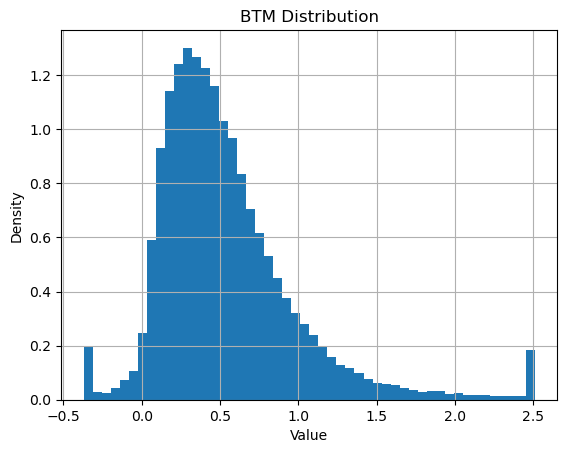

In [99]:
sent_df['btm'].hist(bins=50, density=True)
plt.title('BTM Distribution')
plt.xlabel('Value')
plt.ylabel('Density');

In [100]:
sent_df['btm'].quantile(np.linspace(0, 1, 3))

0.0   -0.368712
0.5    0.450019
1.0    2.508930
Name: btm, dtype: float64

In [101]:
sent_df['btm'].describe()

count    75362.000000
mean         0.539978
std          0.445685
min         -0.368712
25%          0.251875
50%          0.450019
75%          0.718016
max          2.508930
Name: btm, dtype: float64

In [102]:
sent_df['btm_q'] = pd.qcut(sent_df['btm'], q=3)
sent_df['btm_q'] = sent_df['btm_q'].astype(str)

In [103]:
df_panel['btm_q'] = pd.qcut(df_panel['btm'], q=3)
df_panel['btm_q'] = df_panel['btm_q'].astype(str)

In [104]:
sent_df['btm_q'].value_counts().sort_index()

btm_q
(-0.37, 0.316]    25121
(0.316, 0.611]    25120
(0.611, 2.509]    25121
nan               33474
Name: count, dtype: int64

In [105]:
btm_segments = set(sent_df['btm_q'])
len(btm_segments)

4

In [107]:
btm_segments

{'(-0.37, 0.316]', '(0.316, 0.611]', '(0.611, 2.509]', np.str_('nan')}

In [108]:
segment_results = {}

for seg in btm_segments:
    if seg != np.str_('nan'):
        df_segment = sent_df[sent_df['btm_q'] == seg].copy()
        _, res_seg = fit_one_factor(df_segment, sentiment_features, control_variables)

        segment_results[seg] = res_seg

In [109]:
for k, v in segment_results.items():
    level0 = ['BTM ' + k] * len(level1) 
    v.columns = pd.MultiIndex.from_arrays([level0, level1])

In [110]:
segments_res_to_save = pd.concat([v for v in segment_results.values()], axis=1)
segments_res_to_save

BTM (0.611, 2.509]                       \
                                        coef      t     r2   pval   
tone                                   0.001  0.292  0.434   0.77   
tone_pos                               0.182  0.654  0.435  0.513   
tone_neg                               0.023  0.272  0.434  0.786   
tone_harvard                          -0.003  -0.99  0.437  0.322   
tone_posharvard                        0.028  0.807  0.436  0.419   
tone_negharvard                        0.053  1.526  0.442  0.127   
rfpred_car01                        0.096***  3.163  0.504  0.002   
svrpred_car01                          0.005  0.794  0.437  0.427   
sldapred_car01                       0.29***  4.798  0.543    0.0   
factorpred_car01                    0.001***  2.854  0.487  0.004   
positive_general                    0.025***  6.171  0.534    0.0   
negative_general                   -0.033*** -4.481  0.479    0.0   
polarity_general                    0.016***  5.676  0.525    0.0   
positive_revenue                       0.003  0.392  0.359  0.695   
negative_revenue                   -0.026*** -4.039  0.461    0.0   
polarity_revenue                    0.018***  3.398  0.433  0.001   
positive_profit                        0.011   0.98  0.362  0.327   
negative_profit                    -0.056*** -4.651  0.492    0.0   
polarity_profit                     0.047***  4.442  0.489    0.0   
positive_strategic_risk             0.011***  4.004   0.42    0.0   
negative_strategic_risk             -0.01*** -3.173  0.412  0.002   
polarity_strategic_risk             0.007***  4.011  0.433    0.0   
positive_operational_risk            0.01***  3.535   0.41    0.0   
negative_operational_risk          -0.013*** -3.694  0.435    0.0   
polarity_operational_risk           0.007***  4.134  0.441    0.0   
positive_financial_risk             0.011***  3.794  0.425    0.0   
negative_financial_risk            -0.029*** -5.671  0.588    0.0   
polarity_financial_risk             0.012***  5.394  0.527    0.0   
positive_reputation_risk               0.003  0.621   0.36  0.534   
negative_reputation_risk               0.004  1.066  0.363  0.286   
polarity_reputation_risk              -0.001 -0.466  0.359  0.641   
positive_compliance_risk            0.008***  2.711  0.386  0.007   
negative_compliance_risk           -0.012*** -2.664  0.399  0.008   
polarity_compliance_risk            0.006***  3.069  0.402  0.002   
positive_growth_MB                     0.001  0.342  0.323  0.732   
negative_growth_MB                    -0.002 -0.759  0.325  0.448   
polarity_growth_MB                     0.001  0.539  0.324   0.59   
positive_growth_llama               0.011***  5.024  0.467    0.0   
negative_growth_llama              -0.019*** -4.474  0.455    0.0   
polarity_growth_llama               0.008***  5.127  0.477    0.0   

                          BTM (-0.37, 0.316]                       \
                                        coef      t     r2   pval   
tone                                  -0.002 -1.152  0.607  0.249   
tone_pos                             -0.456* -1.782  0.616  0.075   
tone_neg                               0.126  1.322  0.609  0.186   
tone_harvard                       -0.015*** -4.638  0.675    0.0   
tone_posharvard                       -0.013 -0.265  0.602  0.791   
tone_negharvard                      0.15***  4.206  0.657    0.0   
rfpred_car01                           0.029  0.949  0.608  0.343   
svrpred_car01                          0.009  1.207  0.611  0.228   
sldapred_car01                       0.147**  2.482  0.629  0.013   
factorpred_car01                       0.001  1.536  0.616  0.125   
positive_general                    0.024***  5.835  0.712    0.0   
negative_general                   -0.039*** -5.093  0.701    0.0   
polarity_general                    0.016***  5.751  0.721    0.0   
positive_revenue                       0.007  0.984  0.559  0.325   
negative_revenue       

In [329]:
# with pd.ExcelWriter(excel_file, engine='xlsxwriter') as writer:
#     res_to_save.to_excel(writer, sheet_name='Replicate Frankel', index=True)
#     panel_res_to_save.to_excel(writer, sheet_name='Panel one-factor regressions', index=True)
#     industries_res_to_save.to_excel(writer, sheet_name='Industries regressions', index=True)
#     segments_res_to_save.to_excel(writer, sheet_name='BTM segments', index=True)

## Volume

In [111]:
df_panel['log_volume'] = np.log(df_panel['volume'])
sent_df['log_volume'] = np.log(sent_df['volume'])

In [112]:
_, log_volume_res = fit_one_factor_panel(df_panel, 'log_volume', sentiment_features, control_variables, entity_effects=True, time_effects=True)

100%|██████████| 40/40 [00:50<00:00,  1.26s/it]


In [113]:
log_volume_res

,coef,t,r2,pval
tone,-0.399***,-21.946,55.275,0.0
tone_pos,-20.323***,-8.604,54.996,0.0
tone_neg,28.479***,28.718,55.508,0.0
tone_harvard,-0.17***,-5.664,54.967,0.0
tone_posharvard,-2.202***,-4.124,54.957,0.0
tone_negharvard,1.346***,3.67,54.954,0.0
rfpred_car01,-1.109***,-8.154,54.991,0.0
svrpred_car01,-0.05,-1.569,54.947,0.117
sldapred_car01,-5.033***,-14.456,55.089,0.0
factorpred_car01,-0.016***,-8.216,54.992,0.0


In [338]:
# _, volume_res = fit_one_factor_panel(df_panel, 'volume', sentiment_features, control_variables, entity_effects=True, time_effects=True)

In [339]:
# volume_res

In [347]:
# _, log_volume_res_ = fit_one_factor(sent_df, sentiment_features, control_variables, 'log_volume')

In [350]:
# log_volume_res_

In [351]:
level0 = ['Volume'] * len(level1)
log_volume_res.columns = pd.MultiIndex.from_arrays([level0, level1])

In [353]:
# with pd.ExcelWriter(excel_file, engine='xlsxwriter') as writer:
#     res_to_save.to_excel(writer, sheet_name='Replicate Frankel', index=True)
#     panel_res_to_save.to_excel(writer, sheet_name='Panel one-factor regressions', index=True)
#     industries_res_to_save.to_excel(writer, sheet_name='Industries regressions', index=True)
#     segments_res_to_save.to_excel(writer, sheet_name='BTM segments', index=True)
#     log_volume_res.to_excel(writer, sheet_name='Log Volume regressions', index=True)

## RF

In [379]:
Xrf = sent_df[sentiment_features + control_variables].copy()
Yres = sent_df[target].copy()
# Yres

In [382]:
random_grid = {
    'n_estimators': [100, 150, 200],
    'max_features': ['sqrt',],
    'max_depth': [3, 4, 5],
    'min_samples_split': [28, 29, 30, 31, 32,],
    'min_samples_leaf': [11, 12, 13, 14, 15],
    'bootstrap': [True]
    }

In [384]:
rf_random_res = RandomizedSearchCV(estimator=rf_llama_res,
                               param_distributions=random_grid,
                               n_iter=200, cv=5, verbose=4, random_state=108, n_jobs=mp.cpu_count())

In [385]:
rf_random_res

RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(max_depth=5,
                                                   max_features='sqrt',
                                                   min_samples_leaf=9,
                                                   min_samples_split=29,
                                                   n_estimators=150,
                                                   oob_score=True,
                                                   random_state=108),
                   n_iter=200, n_jobs=152,
                   param_distributions={'bootstrap': [True],
                                        'max_depth': [3, 4, 5],
                                        'max_features': ['sqrt'],
                                        'min_samples_leaf': [11, 12, 13, 14,
                                                             15],
                                        'min_samples_split': [28, 29, 30, 31,
                                  

In [386]:
rf_random_res.fit(Xrf, Yres)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(max_depth=5,
                                                   max_features='sqrt',
                                                   min_samples_leaf=9,
                                                   min_samples_split=29,
                                                   n_estimators=150,
                                                   oob_score=True,
                                                   random_state=108),
                   n_iter=200, n_jobs=152,
                   param_distributions={'bootstrap': [True],
                                        'max_depth': [3, 4, 5],
                                        'max_features': ['sqrt'],
                                        'min_samples_leaf': [11, 12, 13, 14,
                                                             15],
                                        'min_samples_split': [28, 29, 30, 31,
                                  

In [387]:
print(f'Best Parameters: {rf_random_res.best_params_} \n')

Best Parameters: {'n_estimators': 200, 'min_samples_split': 28, 'min_samples_leaf': 13, 'max_features': 'sqrt', 'max_depth': 5, 'bootstrap': True} 



In [398]:
rf_hyper.update(rf_random_res.best_params_)
print(f'Current Hyperparams: {rf_hyper} \n')

rf_llama_res = RandomForestRegressor(**rf_hyper)
rf_llama_res.fit(Xrf,Yres)
# print(rf_llama_res.feature_names_in_)

Current Hyperparams: {'n_estimators': 200, 'max_depth': 5, 'min_samples_split': 28, 'min_samples_leaf': 13, 'max_features': 'sqrt', 'bootstrap': True, 'oob_score': True, 'random_state': 108} 



RandomForestRegressor(max_depth=5, max_features='sqrt', min_samples_leaf=13,
                      min_samples_split=28, n_estimators=200, oob_score=True,
                      random_state=108)

In [415]:
rf_llama_res.feature_names_in_[[3, 2, 1]]

array(['tone_harvard', 'tone_neg', 'tone_pos'], dtype=object)

In [471]:
rf_llama_res.oob_score_

0.0068191121874559

In [423]:
def plot_feature_importance(model, names, threshold=None, kind="impurity", data=None, path=None):

    if kind=="impurity":
        feature_importance_df = pd.DataFrame.from_dict({'feature_importance': model.feature_importances_,
                                                        'Feature': model.feature_names_in_})\
        .set_index('Feature').sort_values('feature_importance', ascending=True)
        
        if threshold is not None:
            feature_importance_df = feature_importance_df[feature_importance_df.feature_importance > threshold]

        plt.clf();
        feature_importance_df.plot.bar(color='orange', align='center', legend=None)
        plt.xlabel(None)
        plt.title('Feature Importances')
        plt.ylabel('Average Impurity Decrease')
        plt.xticks(rotation=30, ha='right');


    elif kind=="permutation":
        if not data:
            print("data arg mandatory for permutation feature importance")
            return None

        result = permutation_importance(model, data['X'], data['Y'], n_repeats=30, random_state=108, n_jobs=2)

        sorted_importances_idx = result.importances_mean.argsort()
        importances = pd.DataFrame(
            result.importances[sorted_importances_idx].T,
            columns=[data['X_labels'][c] for c in data['X'].columns[sorted_importances_idx]],
        )
        ax = importances.plot.box(vert=False, whis=10)
        ax.set_title("Permutation Importances")
        ax.axvline(x=0, color="k", linestyle="--")
        ax.set_xlabel("Decrease in accuracy score")
        ax.figure.tight_layout()

    elif kind=="both":
        feature_importance_df = pd.DataFrame.from_dict({'feature_importance': model.feature_importances_,
                                                        'Feature': model.feature_names_in_})\
        .set_index('Feature').sort_values('feature_importance', ascending=True)
        
        if threshold is not None:
            feature_importance_df = feature_importance_df[feature_importance_df.feature_importance > threshold]

        if not data:
            print("data arg mandatory for permutation feature importance")
            return None

        perm_result = permutation_importance(model, data['X'], data['Y'], n_repeats=30, random_state=108, n_jobs=8)
#         print(perm_result)

        sorted_importances_idx = perm_result.importances_mean.argsort()
        perm_importances = pd.DataFrame(
            perm_result.importances[sorted_importances_idx].T,
            columns=model.feature_names_in_[sorted_importances_idx],
        )

        plt.clf();
        sns.set(style="ticks")
        figure, (ax1,ax2) = plt.subplots(1, 2, figsize=(18, 6), sharey=False, sharex=False, squeeze=True,)

        feature_importance_df.plot.bar(color='lightblue', align='center', legend=None, ax=ax1, edgecolor='black')
        ax1.set_xlabel('')
        ax1.set_title('Feature Importances')
        ax1.grid()
        ax1.set_ylabel('Average Impurity Decrease')

        perm_importances.plot.box(vert=True, whis=10, ax=ax2)
        ax2.set_title("Permutation Importances")
        ax2.axhline(y=0, color="k", linestyle="--")
        ax2.set_ylabel("Decrease in MSE")
        ax2.grid()
        ax2.tick_params(axis='x', labelrotation=90)

        if path:
#             path = join(tables_path, path)
            plt.savefig(path, bbox_inches='tight');
            plt.show();

<Figure size 432x288 with 0 Axes>

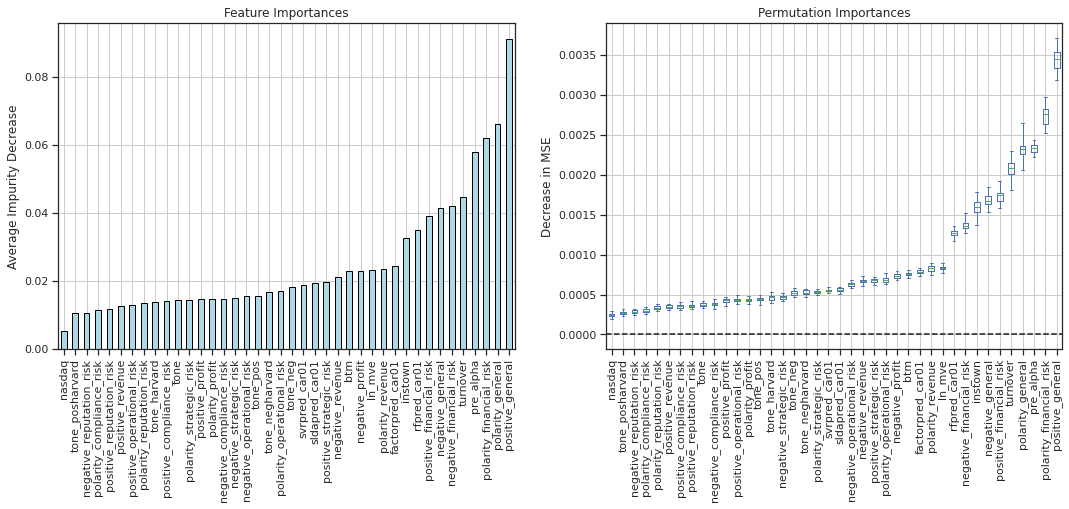

In [424]:
plot_feature_importance(rf_llama_res, rf_llama_res.feature_names_in_,
                        kind="both", data=dict(X=Xrf, Y=Yres), path='figures/random_forest_importance.png')

In [437]:
def plot_partial_dependence(estimator,
                            X,
                            feature=0,
#                             categorical_features=[True]*8+[False]*2,
                            figsize=(5, 5),
                            X_labels=None,
                            path=None,
                            rotation=25,
                            ols=None,
                            pt=(0.1,0.9),
                            axs=None):
    """
    Plot partial dependence for features
    """

    plt.clf();
    if not axs:
        fig, axs = plt.subplots(figsize=figsize);
    #     pdd_opts = dict(response_method="predict_proba", kind='average', n_jobs=-1, method='brute')
    pdd_opts = dict(response_method="predict", kind='average', n_jobs=-1, method='brute')

    X_labels = [X_labels[c] for c in X.columns] if X_labels else X.columns.tolist()

    pdd = PartialDependenceDisplay.from_estimator(estimator=estimator,
                                                    X=X,
                                                    features=[feature],
                                                    feature_names=X_labels,
                                                    percentiles=pt,
#                                                         categorical_features=categorical_features,
                                                    **pdd_opts,ax=axs);
    try:
        pdd.axes_[0,0].set_ylabel("Average Response Probability");
        pdd.axes_[0,0].set_xlabel(X_labels[feature]);
        pdd.axes_[0,0].set_yticks(np.arange(0.2, 0.85, 0.1));
        pdd.axes_[0,0].tick_params(axis='x', labelrotation=rotation,labelsize=11);
        pdd.axes_[0,0].tick_params(axis='y', labelsize=11);

        labels = cat[X.columns[feature]]
        pdd.axes_[0,0].set_xticks(list(range(len(labels))), labels=labels);
        for c in range(len(labels)):
            pdd.axes_[0,0].get_children()[c].set_color((0.8,0.5,0,0.5));

    except:
        print(f"Continuous feature")
        perc = np.percentile(X[X.columns[feature]],pt)
#         xs = np.linspace(perc[0],perc[1],10)
#         ys = ols_mx(ols['result'], X.columns[feature], xs, res_df, ols['formula'])
        pdd.axes_[0,0].get_children()[0].set_label('RF')
#         pdd.axes_[0,0].plot(xs, ys, 'g--', linewidth=.75, label='OLS')
        pdd.axes_[0,0].legend(loc='upper left')


    if path:
#         path = join(tables_path, path)
        plt.savefig(path, bbox_inches="tight");
        plt.show();
    return pdd


In [455]:
sample = Xrf.sample(n=10_000, random_state=108)
sample.shape

(10000, 40)

In [456]:
# name = 'polarity_general'

# plot_partial_dependence(estimator=rf_llama_res,
#                         X=sample,
#                         feature=name,
#                         X_labels=None,
#                         figsize=(6, 5), rotation=0, path=None,
#                         ols=None)

In [444]:
sample.head(2)

,tone,tone_pos,tone_neg,tone_harvard,tone_posharvard,tone_negharvard,rfpred_car01,svrpred_car01,sldapred_car01,factorpred_car01,positive_general,negative_general,polarity_general,positive_revenue,negative_revenue,polarity_revenue,positive_profit,negative_profit,polarity_profit,positive_strategic_risk,negative_strategic_risk,polarity_strategic_risk,positive_operational_risk,negative_operational_risk,polarity_operational_risk,positive_financial_risk,negative_financial_risk,polarity_financial_risk,positive_reputation_risk,negative_reputation_risk,polarity_reputation_risk,positive_compliance_risk,negative_compliance_risk,polarity_compliance_risk,ln_mve,btm,turnover,pre_alpha,instown,nasdaq
13169,-0.128205,0.004600,0.005953,0.215980,0.043925,0.028321,-0.002070,-0.006763,-0.002266,-0.510253,0.197678,0.106785,0.090893,0.166107,0.113708,0.052399,0.216934,0.096146,0.120789,0.112671,0.368340,-0.255669,0.088364,0.385834,-0.297470,0.151802,0.351883,-0.200081,0.046898,0.363201,-0.316303,0.151405,0.349594,-0.198189,4.789323,0.193553,4.563250,-0.001870,0.276729,1.0
30833,-0.505426,0.004517,0.013750,0.101628,0.059405,0.048444,0.006121,0.018980,-0.002019,0.268987,0.081177,0.242418,-0.161242,0.178711,0.134033,0.044678,0.174927,0.095657,0.079269,0.132965,0.256329,-0.123363,0.112503,0.254955,-0.142452,0.110588,0.241581,-0.130993,0.095928,0.240871,-0.144943,0.147388,0.213326,-0.065937,7.886634,0.766056,4.453114,-0.000265,1.000000,1.0


In [457]:
features_to_analyse = ['tone', 'rfpred_car01', 'factorpred_car01',
                       'polarity_general', 'positive_general', 'negative_general',
                       'polarity_financial_risk', 'polarity_profit', 'polarity_revenue']
features_indices = list(np.argwhere(sample.columns.isin(features_to_analyse)).ravel())
features_indices

[0, 6, 9, 10, 11, 12, 15, 18, 27]

In [458]:
# sample = sample[features_to_analyse].reset_index(drop=True)

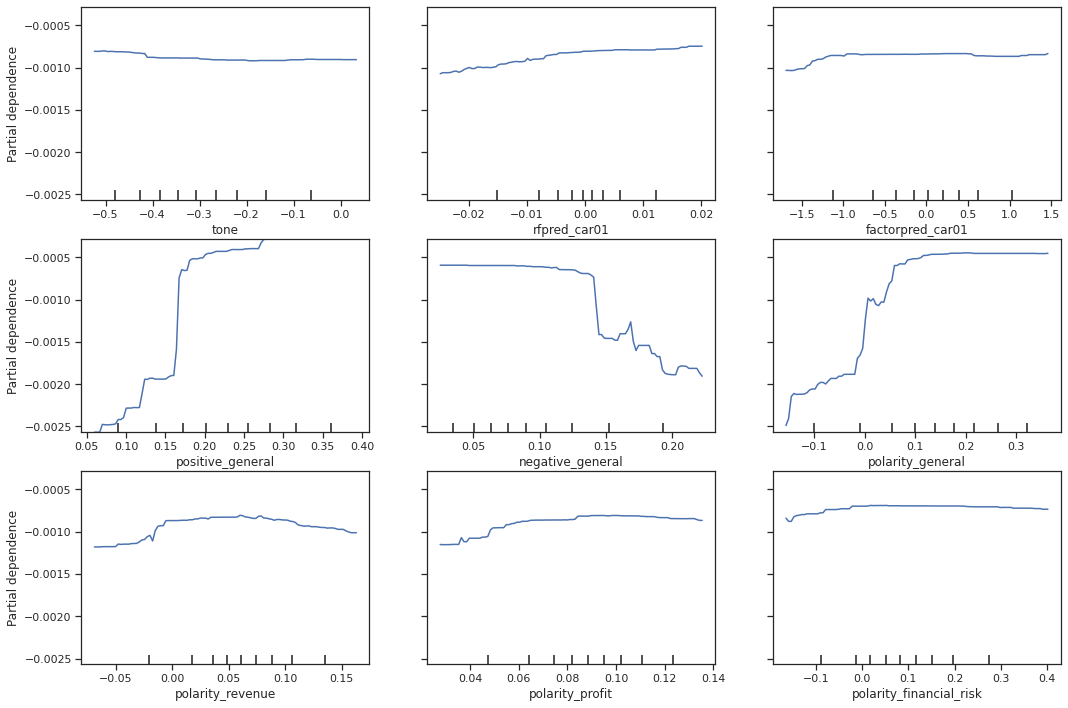

In [480]:
fig, ax = plt.subplots(figsize=(15, 10))


PartialDependenceDisplay.from_estimator(
    rf_llama_res, 
    sample,
    features=features_indices,
    feature_names=sample.columns,
    ax=ax,
#     grid_resolution=50
)

plt.tight_layout()
# plt.tight_layout(pad=3.0)
ax.grid(True, which='both', alpha=0.4, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# ax.minorticks_on()
# ax.grid(True, which='minor', alpha=0.2, linestyle=':', linewidth=0.5)

plt.savefig('figures/pdp_all_sentiments.png')
plt.show()

## Interaction term

In [114]:
sent_df['intercation_term'] = sent_df['polarity_growth_MB'] * sent_df['btm']

In [115]:
df_panel['intercation_term'] = df_panel['polarity_growth_MB'] * df_panel['btm']

In [116]:
# df_panel['btm_q']

In [117]:
# sentiment_features

In [121]:
segment_results = {}
segment_models = {}

for seg in btm_segments:
    if seg != np.str_('nan'):
        df_segment = sent_df[sent_df['btm_q'] == seg].copy()
        model_seg, res_seg = fit_one_factor(df_segment, ['polarity_general'], control_variables + ['intercation_term'])
        segment_models[seg] = model_seg
        segment_results[seg] = res_seg

In [122]:
for k, v in segment_results.items():
    level0 = ['BTM ' + k] * len(level1) 
    v.columns = pd.MultiIndex.from_arrays([level0, level1])

In [123]:
interaction_term = pd.concat([v for v in segment_results.values()], axis=1)
interaction_term

BTM (0.611, 2.509]                    BTM (-0.37, 0.316]  \
                               coef      t     r2 pval               coef   
polarity_general           0.014***  5.113  0.472  0.0           0.016***   

                                    BTM (0.316, 0.611]                     
                      t     r2 pval               coef      t     r2 pval  
polarity_general  5.771  0.737  0.0           0.012***  4.569  0.384  0.0

In [126]:
# x = segment_models['(-0.37, 0.314]']['polarity_growth_MB']['model']

In [127]:
# print(x.summary())

In [128]:
# x = segment_models['(0.314, 0.612]']['polarity_general']['model']

In [129]:
# print(x.summary())

In [524]:
# x = segment_models['(0.612, 2.509]']['polarity_general']['model']

In [130]:
# print(x.summary())

In [527]:
df_panel

datadate  prcc_f     csho       ceq   instown   permco  \
gvkey     year                                                               
b'001004' 2002.0  2002-05-31   11.44   31.870   310.235  0.903180  20000.0   
          2003.0  2003-05-31    4.50   31.851   294.988  0.900913  20000.0   
          2004.0  2004-05-31    9.58   32.245   301.684  0.901062  20000.0   
          2005.0  2005-05-31   16.04   32.586   314.744  1.000000  20000.0   
          2006.0  2006-05-31   24.08   36.654   422.717  1.000000  20000.0   
...                      ...     ...      ...       ...       ...      ...   
b'317264' 2017.0  2017-03-31   10.53   54.975   976.002  0.000000  54852.0   
          2018.0  2018-03-31    7.49   55.090   959.413  0.565377  54852.0   
          2019.0  2019-03-31    6.42   55.168   912.683  0.529435  54852.0   
b'318728' 2018.0  2017-12-31   51.71  199.853  9208.000  0.000000  55804.0   
          2019.0  2018-12-31   39.83  197.100  8276.000  0.722051  55804.0   

                   permno  date_filed                         filename  \
gvkey     year                                                           
b'001004' 2002.0  54594.0  2002-08-26     b'1750_0000912057-02-033450'   
          2003.0  54594.0  2003-08-18     b'1750_0001047469-03-028005'   
          2004.0  54594.0  2004-07-22     b'1750_0001047469-04-023905'   
          2005.0  54594.0  2005-07-22     b'1750_0001104659-05-033688'   
          2006.0  54594.0  2006-07-17     b'1750_0001104659-06-047248'   
...                   ...         ...                              ...   
b'317264' 2017.0  14642.0  2017-06-14  b'1596993_0001596993-17-000010'   
          2018.0  14642.0  2018-06-28  b'1596993_0001596993-18-000015'   
          2019.0  14642.0  2019-05-30  b'1596993_0001596993-19-000010'   
b'318728' 2018.0  16496.0  2018-02-26  b'1527469_0001527469-18-000011'   
          2019.0  16496.0  2019-02-27  b'1527469_0001527469-19-000007'   

                          mve       btm       volume    SHROUT  turnover  \
gvkey     year                                                             
b'001004' 2002.0    364.59280  0.850908   32389900.0   26860.0  1.205879   
          2003.0    143.32950  2.058111   21138500.0   31850.0  0.663689   
          2004.0    308.90710  0.976617   41549083.0   32245.0  1.288543   
          2005.0    522.67944  0.602174   47055900.0   32438.0  1.450641   
          2006.0    882.62832  0.478930   97373000.0   36461.0  2.670607   
...                       ...       ...          ...       ...       ...   
b'317264' 2017.0    578.88675  1.685998   59346255.0   54967.0  1.079671   
          2018.0    412.62410  2.325150   58762972.0   55107.0  1.066343   
          2019.0    354.17856  2.508930   40707109.0   55167.0  0.737889   
b'318728' 2018.0  10334.39863  0.891005  334320819.0  142348.0  2.348616   
          2019.0   7850.49300  1.054201  338861633.0  164849.0  2.055588   

                  pre_alpha  nasdaq     car01  tone_pos  tone_neg      tone  \
gvkey     year                                                                
b'001004' 2002.0  -0.002825     0.0 -0.001721  0.004142  0.007198 -0.269461   
          2003.0  -0.000024     0.0  0.144115  0.003915  0.007516 -0.315068   
          2004.0   0.000483     0.0 -0.050975  0.004134  0.007463 -0.287037   
          2005.0   0.001064     0.0 -0.003768  0.004717  0.007433 -0.223529   
          2006.0   0.001258     0.0  0.000631  0.005518  0.009995 -0.288557   
...                     ...     ...       ...       ...       ...       ...   
b'317264' 2017.0  -0.000467     0.0 -0.029018  0.005495  0.014015 -0.436735   
          2018.0  -0.000395     0.0 -0.047430  0.005525  0.014667 -0.452713   
          2019.0   0.000974     0.0 -0.027795  0.005649  0.013585 -0.412628   
b'318728' 2018.0  -0.000431     0.0 -0.001046  0.007346  0.013908 -0.308759   
          2019.0  -0.000151     0.0  0.006164  0.007526  0.013676 -0.290089   

                  tone_po

In [551]:
# segment_results = {}
# segment_models = {}

# for seg in btm_segments:
#     df_panel_seg = df_panel[df_panel['btm_q'] == seg].copy()
# #     model_seg, res_seg = fit_one_factor(df_segment, ['polarity_general'], control_variables + ['intercation_term'])

#     model_seg, res_seg = fit_one_factor_panel(df_panel_seg, target, ['polarity_general'],
#                                               control_variables + ['intercation_term'],
#                                               entity_effects=True, time_effects=True)
#     segment_models[seg] = model_seg
#     segment_results[seg] = res_seg

In [552]:
# for k, v in segment_results.items():
#     level0 = ['BTM ' + k] * len(level1) 
#     v.columns = pd.MultiIndex.from_arrays([level0, level1])

In [553]:
# interaction_term = pd.concat([v for v in segment_results.values()], axis=1)
# interaction_term

In [542]:
# x = segment_models['(-0.37, 0.314]']['polarity_general']['model']
# print(x)

In [543]:
# x = segment_models['(0.612, 2.509]']['polarity_general']['model']
# print(x)

In [132]:
def ols_with_cluster(data, target, x_vars, cluster_var):

    subset = data.dropna(subset=[target] + x_vars + [cluster_var])
    X = add_constant(subset[x_vars])
    y = subset[target]
    clusters = subset[cluster_var]
    
    model = OLS(y, X).fit()

    results = model.get_robustcov_results(cov_type='cluster', groups=clusters)
    return results

In [133]:
# df_panel.head()

In [134]:
formula = f"{target} ~ polarity_growth_MB + ln_mve + btm + turnover + pre_alpha + instown + nasdaq + polarity_growth_MB*btm"

model = PanelOLS.from_formula(formula, df_panel, drop_absorbed=True)
results = model.fit()

In [135]:
print(results)

                          PanelOLS Estimation Summary                           
Dep. Variable:                  car01   R-squared:                        0.0045
Estimator:                   PanelOLS   R-squared (Between):              0.0188
No. Observations:               63005   R-squared (Within):               0.0015
Date:                Thu, Feb 05 2026   R-squared (Overall):              0.0045
Time:                        19:37:25   Log-likelihood                 1.004e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      35.341
Entities:                        9179   P-value                           0.0000
Avg Obs:                       6.8640   Distribution:                 F(8,62997)
Min Obs:                       1.0000                                           
Max Obs:                       25.000   F-statistic (robust):             35.341
                            

In [137]:
# formula = f"{target} ~ polarity_growth_MB + ln_mve + btm + turnover + pre_alpha + instown + nasdaq + polarity_growth_MB*btm"
# model = OLS.from_formula(formula, sent_df, drop_absorbed=True)
# model = model.fit()

# results = model.get_robustcov_results(cov_type='cluster', groups=sent_df['gvkey'])

In [138]:
# print(results.summary())

In [139]:
formula = f"{target} ~ TimeEffects + polarity_growth_MB + ln_mve + btm + turnover + pre_alpha + instown + nasdaq + polarity_growth_MB*ln_mve"

model = PanelOLS.from_formula(formula, df_panel, drop_absorbed=True)
results = model.fit()

In [140]:
print(results)

                          PanelOLS Estimation Summary                           
Dep. Variable:                  car01   R-squared:                        0.0039
Estimator:                   PanelOLS   R-squared (Between):             -0.0070
No. Observations:               63005   R-squared (Within):               0.0012
Date:                Thu, Feb 05 2026   R-squared (Overall):             -0.0035
Time:                        19:37:51   Log-likelihood                 1.004e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      30.737
Entities:                        9179   P-value                           0.0000
Avg Obs:                       6.8640   Distribution:                 F(8,62973)
Min Obs:                       1.0000                                           
Max Obs:                       25.000   F-statistic (robust):             30.737
                            

In [142]:
# formula = f"{target} ~ polarity_growth_MB + ln_mve + btm + turnover + pre_alpha + instown + nasdaq + polarity_growth_MB*ln_mve"
# model = OLS.from_formula(formula, sent_df, drop_absorbed=True)
# model = model.fit()

# results = model.get_robustcov_results(cov_type='cluster', groups=sent_df['gvkey'])
# print(results.summary())

In [143]:
# sent_df['ln_mve'].hist(bins=50)

In [144]:
# sent_df['mve'].hist(bins=50)

## Figure 1
Filing Returns and Sentiment

In [147]:
sent_df_ = sent_df.copy()

In [148]:
quantile_feats = ['rfpred_car01', 'tone', 'tone_harvard', 'polarity_general', 'polarity_growth_MB', 'polarity_growth_llama']

for f in quantile_feats:
    sent_df_[f'{f}_quintile'] = pd.qcut(sent_df_[f], q=5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'], duplicates='drop')

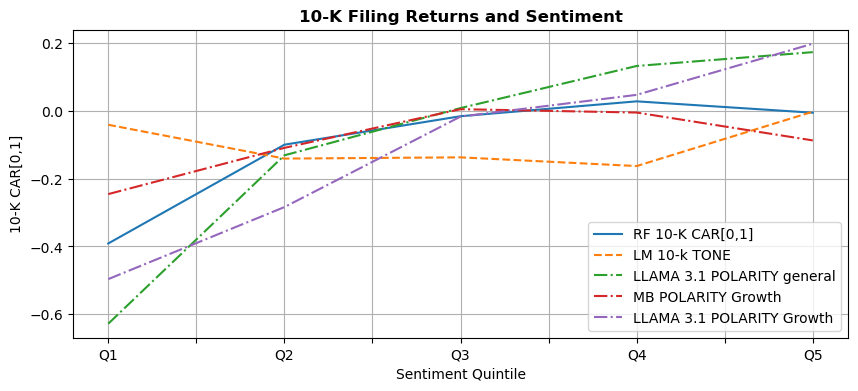

In [151]:
plt.figure(figsize=(10, 4))
plt.title('10-K Filing Returns and Sentiment', weight='bold')
(100*sent_df_.groupby(['rfpred_car01_quintile'])[target].mean()).plot(label='RF 10-K CAR[0,1]')
(100*sent_df_.groupby(['tone_quintile'])[target].mean()).plot(label='LM 10-k TONE', style='--')
# (100*df_.groupby(['tone_harvard_quintile'])[target].mean()).plot(label='HARV 10-K TONE', style=':')
(100*sent_df_.groupby(['polarity_general_quintile'])[target].mean()).plot(label='LLAMA 3.1 POLARITY general', style='-.')
(100*sent_df_.groupby(['polarity_growth_MB_quintile'])[target].mean()).plot(label='MB POLARITY Growth', style='-.')
(100*sent_df_.groupby(['polarity_growth_llama_quintile'])[target].mean()).plot(label='LLAMA 3.1 POLARITY Growth', style='-.')
plt.ylabel('10-K CAR[0,1]')
plt.xlabel('Sentiment Quintile')
plt.grid()
plt.legend();

In [154]:
quantile_feats = ['rfpred_car01', 'tone', 'tone_harvard', 'polarity_general', 'polarity_growth_MB', 'polarity_growth_llama']

for f in quantile_feats:
    sent_df_[f'{f}_quintile'] = pd.qcut(sent_df_[f], q=10,  duplicates='drop')

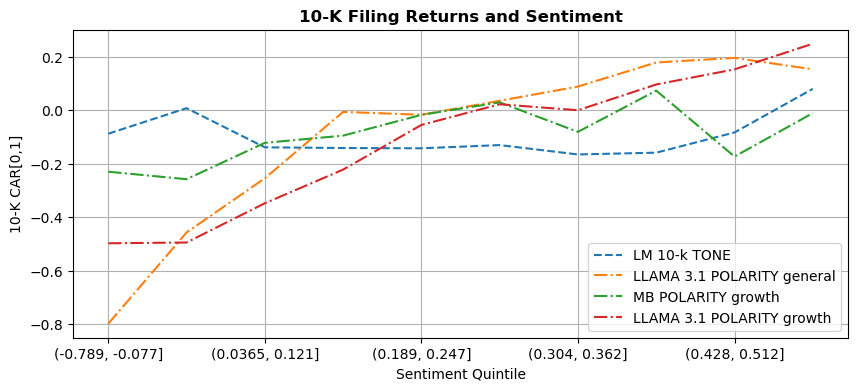

In [156]:
plt.figure(figsize=(10, 4))
plt.title('10-K Filing Returns and Sentiment', weight='bold')
# (100*sent_df_.groupby(['rfpred_car01_quintile'])[target].mean()).plot(label='RF 10-K CAR[0,1]')
(100*sent_df_.groupby(['tone_quintile'])[target].mean()).plot(label='LM 10-k TONE', style='--')

(100*sent_df_.groupby(['polarity_general_quintile'])[target].mean()).plot(label='LLAMA 3.1 POLARITY general', style='-.')
(100*sent_df_.groupby(['polarity_growth_MB_quintile'])[target].mean()).plot(label='MB POLARITY growth', style='-.')
(100*sent_df_.groupby(['polarity_growth_llama_quintile'])[target].mean()).plot(label='LLAMA 3.1 POLARITY growth', style='-.')
plt.ylabel('10-K CAR[0,1]')
plt.xlabel('Sentiment Quintile')
plt.grid()
plt.legend();

In [157]:
df

,gvkey,datadate,prcc_f,csho,ceq,instown,permco,permno,date_filed,filename,mve,btm,volume,SHROUT,turnover,pre_alpha,nasdaq,car01,tone_pos,tone_neg,tone,tone_posharvard,tone_negharvard,tone_harvard,rfpred_car01,svrpred_car01,sldapred_car01,year,ln_mve,factorpred_car01
0,b'001004',1996-05-31,22.124999,15.998,204.635,0.769911,20000.0,54594.0,1996-08-20,b'1750_0000912057-96-018355',353.955727,0.578137,8818300.0,16025.0,550.283931,0.000422,0.0,-0.004494,0.007245,0.006079,0.087500,0.052049,0.028065,0.299376,0.005316,0.031102,0.000190,1996.0,5.869172,0.661720
1,b'001004',1997-05-31,30.999985,18.204,269.259,0.832853,20000.0,54594.0,1997-08-22,b'1750_0000912057-97-028915',564.323722,0.477136,21456200.0,18156.0,1181.769112,0.001376,0.0,0.005077,0.006206,0.004227,0.189655,0.053872,0.025992,0.349099,0.000997,-0.008040,0.000435,1997.0,6.335628,-0.175370
2,b'001004',1998-05-31,26.437500,27.704,300.850,0.893793,20000.0,54594.0,1998-08-20,b'1750_0001047469-98-032283',732.424500,0.410759,18200800.0,27690.0,657.305887,0.000424,0.0,0.025747,0.005877,0.002978,0.327434,0.050854,0.022802,0.380851,0.002169,0.024143,-0.000279,1998.0,6.596360,0.229395
3,b'001004',1999-05-31,19.750000,27.381,326.035,0.804165,20000.0,54594.0,1999-08-18,b'1750_0001047469-99-032978',540.774750,0.602904,25769400.0,27443.0,939.015414,-0.000434,0.0,0.014496,0.005442,0.002918,0.301887,0.053238,0.022005,0.415094,0.007558,0.016321,0.002568,1999.0,6.293003,0.567987
4,b'001004',2000-05-31,13.875000,26.865,339.515,0.727921,20000.0,54594.0,2000-08-24,b'1750_0000912057-00-039006',372.751875,0.910834,25843200.0,26963.0,958.469013,-0.002255,0.0,-0.027259,0.004120,0.003090,0.142857,0.049996,0.022106,0.386813,0.006785,0.020566,0.001088,2000.0,5.920913,0.476806
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75357,b'317264',2017-03-31,10.530000,54.975,976.002,0.000000,54852.0,14642.0,2017-06-14,b'1596993_0001596993-17-000010',578.886750,1.685998,59346255.0,54967.0,1079.670621,-0.000467,0.0,-0.029018,0.005495,0.014015,-0.436735,0.053671,0.033333,0.233754,-0.007481,0.061267,-0.005647,2017.0,6.361107,-0.123893
75358,b'317264',2018-03-31,7.490000,55.090,959.413,0.565377,54852.0,14642.0,2018-06-28,b'1596993_0001596993-18-000015',412.624100,2.325150,58762972.0,55107.0,1066.343151,-0.000395,0.0,-0.047430,0.005525,0.014667,-0.452713,0.052688,0.033028,0.229364,-0.012188,0.007985,0.001820,2018.0,6.022537,-0.338591
75359,b'317264',2019-03-31,6.420000,55.168,912.683,0.529435,54852.0,14642.0,2019-05-30,b'1596993_0001596993-19-000010',354.178560,2.508930,40707109.0,55167.0,737.888756,0.000974,0.0,-0.027795,0.005649,0.013585,-0.412628,0.054438,0.032027,0.259187,-0.016984,-0.063728,0.008236,2019.0,5.869801,-0.797175
75360,b'318728',2017-12-31,51.710000,199.853,9208.000,0.000000,55804.0,16496.0,2018-02-26,b'1527469_0001527469-18-000011',10334.398630,0.891005,334320819.0,142348.0,2348.616201,-0.000431,0.0,-0.001046,0.007346,0.013908,-0.308759,0.077755,0.048643,0.230316,0.001199,0.015440,0.010414,2018.0,9.243233,0.560623
